In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Simulate the data

## Healthy signal

In [3]:
def X(t,n,A,a,f,sigma):
    x = np.zeros_like(t)
    for i in range(1,n+1):
        x += A*np.power(a,i-1)*np.sin(2*np.pi*f*i*t)
    x += sigma*np.random.normal(0,1,len(t))
    return x

## Faulty signal

In [4]:
def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low,high],btype = 'band')
    return lfilter(b,a,data)

def X_faulty(t, n, A, a, f, sigma, fs):
    x = np.zeros_like(t)
    for i in range(1, n+1):
        x += A*np.power(a,i-1)*np.sin(2*np.pi*f*i*t)
    
    # wygenerować biały szum Gaussa
    noise = np.random.normal(0,1,len(t))
    
    # przepuścić szum przez filtr pasmowy (1000 - 6000 Hz)
    noise_band = bandpass_filter(noise, fs, 1000, 6000)

    # Wygenerować sygnał impulsowy z częstotliwością 13Hz
    f_fault = 13
    n_harm = 15 #zmienimy potem na 6
    impulse_train = np.zeros_like(t)
    for k in range(1, n_harm + 1):
        impulse_train += np.sin(2* np.pi *f_fault*k*t)
    
    # Normalizacja impulsów
    impulse_train = impulse_train / np.max(np.abs(impulse_train))

    # Zmodulować amplitudowo szum filtrowany
    noise_faulty = noise_band*(1 + impulse_train)

    # Dodać sygnał deterministyczny (sumę sinusów)
    x = x + sigma* noise_faulty

    return x

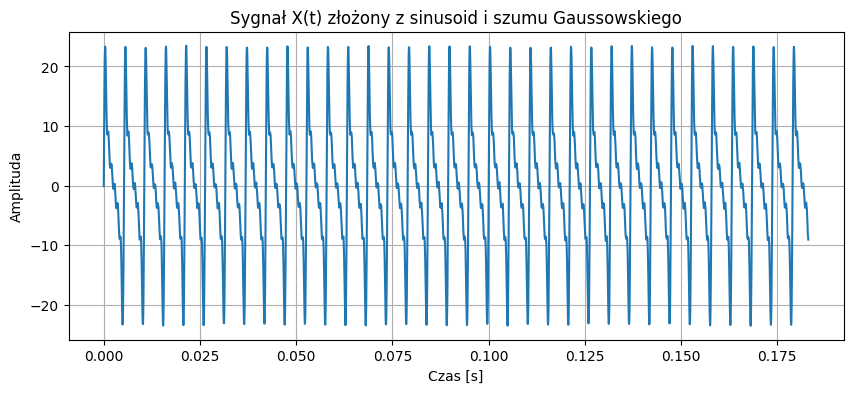

In [5]:
#dane

n = 6
A = 10
a = 0.75
f = 190
sigma = 0.1
fs = 16384
T = 2.5
t = np.linspace(0,T,int(fs*T), endpoint = False)

signal = X(t,n,A,a,f,sigma)

N= 3000 #wycinek

# Rysunek
plt.figure(figsize=(10, 4))
plt.plot(t[:N], signal[:N])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Sygnał X(t) złożony z sinusoid i szumu Gaussowskiego")
plt.grid(True)
plt.show()


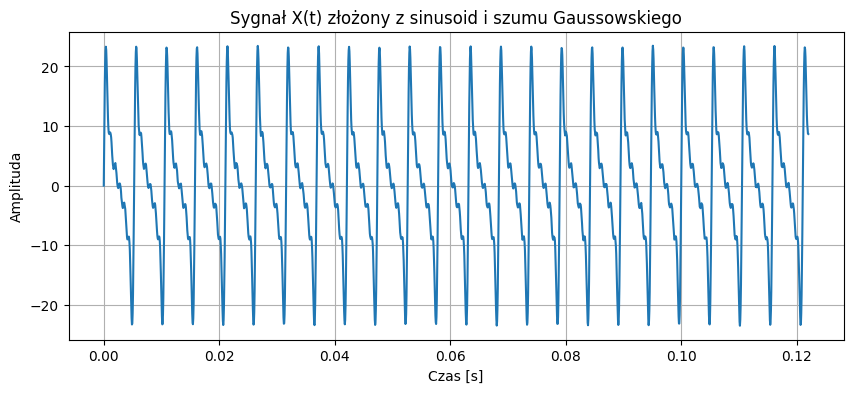

In [6]:
signal_faulty = X_faulty(t,n,A,a,f,sigma,fs)

N= 2000 #wycinek

# Rysunek
plt.figure(figsize=(10, 4))
plt.plot(t[:N], signal_faulty[:N])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Sygnał X(t) złożony z sinusoid i szumu Gaussowskiego")
plt.grid(True)
plt.show()

## Szumy

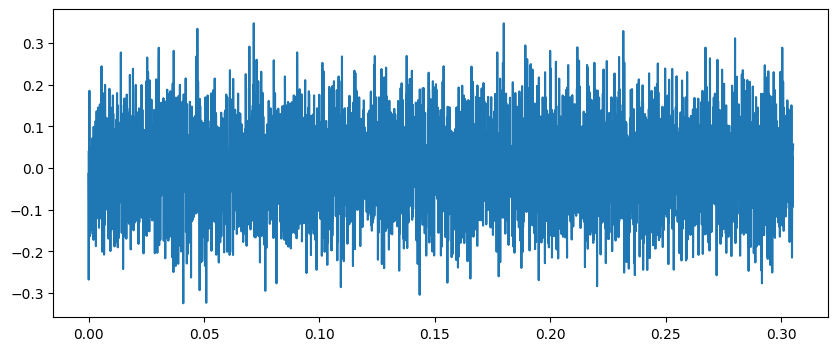

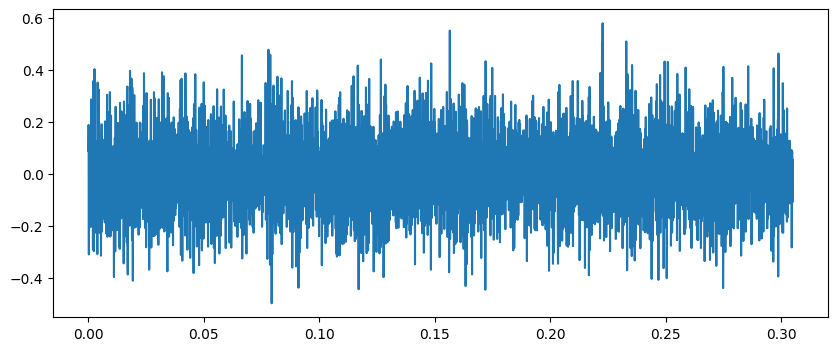

In [7]:
fs = 16384
T = 2.5
t = np.linspace(0,T,int(fs*T), endpoint = False)
wn = sigma* np.random.normal(0,1,len(t))

N =5000

plt.figure(figsize=(10, 4))
plt.plot(t[:N], wn[:N])


# wygenerować biały szum Gaussa
noise_faulty = sigma*np.random.normal(0,1,len(t))

# przepuścić szum przez filtr pasmowy (1000 - 6000 Hz)
noise_band = bandpass_filter(noise_faulty, fs, 1000, 6000)

# Wygenerować sygnał impulsowy z częstotliwością 13Hz
f_fault = 13
n_harm = 10 #zmienimy potem na 6
impulse_train = np.zeros_like(t)
for k in range(1, n_harm + 1):
    impulse_train += np.sin(2* np.pi *f_fault*k*t)

# Normalizacja impulsów
impulse_train = impulse_train / np.max(np.abs(impulse_train))

# Zmodulować amplitudowo szum filtrowany
noise_faulty += noise_band*(1 + impulse_train)

plt.figure(figsize=(10, 4))
plt.plot(t[:N], noise_faulty[:N])

# Wizualizacje

(array([[2.23318563e-02, 5.75147001e-03, 1.49548488e-03, ...,
         1.34633080e-04, 6.16721094e-04, 5.35837531e-06],
        [9.76676369e-02, 2.28035461e-01, 1.73478327e-01, ...,
         2.69895712e-01, 3.90813472e-01, 1.88835388e-01],
        [1.16594750e+03, 1.18814206e+03, 1.17445156e+03, ...,
         1.17207027e+03, 1.19897616e+03, 1.17026678e+03],
        ...,
        [3.74738827e-03, 7.50947282e-04, 6.57123778e-03, ...,
         5.91900820e-03, 5.06273829e-03, 1.04503544e-03],
        [3.54586882e-03, 3.54022527e-03, 3.16333067e-02, ...,
         1.62555998e-02, 8.07451369e-03, 5.80566688e-04],
        [4.62914876e-03, 6.74281939e-04, 2.22061861e-02, ...,
         8.52054151e-03, 8.04678320e-03, 1.83047713e-04]]),
 array([0.       , 0.0078125, 0.015625 , 0.0234375, 0.03125  , 0.0390625,
        0.046875 , 0.0546875, 0.0625   , 0.0703125, 0.078125 , 0.0859375,
        0.09375  , 0.1015625, 0.109375 , 0.1171875, 0.125    , 0.1328125,
        0.140625 , 0.1484375, 0.15625  , 0.

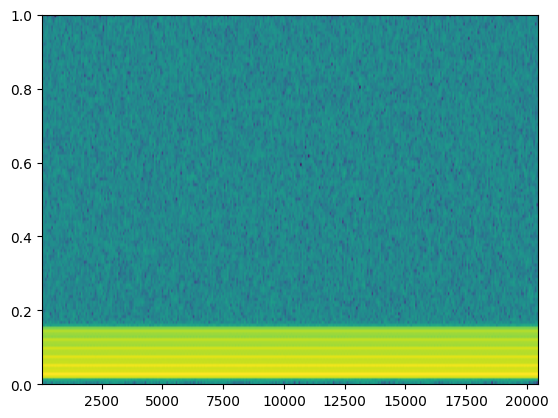

In [8]:
plt.specgram(signal)